# Stock Market Prediction — Part 2: LSTM & Reinforcement Learning
### WnCC, IIT Bombay — Continuation of the SOC project (Linear/Logistic/KNN/CNN already covered in `SOC.ipynb`)

This notebook continues the project from the 1D-CNN stage. It:
1. Reloads the historical NSE data (Reliance, SBI, TCS)
2. Trains an **LSTM** model for next-day price prediction (sequence-native alternative to the CNN)
3. Builds and trains a **Reinforcement Learning (Q-learning) trading agent** that learns a Buy / Hold / Sell policy directly from market signals, and compares it against a Buy & Hold benchmark

All results below are from real, executed runs on the actual `RELIANCE_Yahoo_Historical_Python.csv`, `SBIN_Yahoo_Historical_Python.csv`, `TCS_Yahoo_Historical_Python.csv` files.

## 1. Setup & Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

def load_stock(path):
    df = pd.read_csv(path, skiprows=[1, 2])
    df.columns = ["Date", "Close", "High", "Low", "Open", "Volume"]
    df["Date"] = pd.to_datetime(df["Date"], format="mixed", dayfirst=True)
    return df.sort_values("Date").reset_index(drop=True)

# NOTE: swap in yf.download(ticker, period="1y") if running with internet access;
# here we use the CSVs already collected for the project (5+ years, NSE).
tcs = load_stock("TCS_Yahoo_Historical_Python.csv")
reliance = load_stock("RELIANCE_Yahoo_Historical_Python.csv")
sbin = load_stock("SBIN_Yahoo_Historical_Python.csv")

tcs.tail()

I0000 00:00:1787476973.869475   28524 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787476973.870266   28524 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1787476974.039165   28524 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1787476975.901336   28524 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787476975.901804   28524 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


,Date,Close,High,Low,Open,Volume
1340,2025-11-03,3543.801514,3557.132970,3506.483066,3526.653879,1995450
1341,2025-11-04,3203.030273,3269.885986,3177.754930,3260.568898,7108961
1342,2025-12-02,3915.348877,3986.318174,3905.436977,3936.114500,1678002
1343,2025-12-03,3475.310059,3537.804632,3456.130679,3533.592074,3174167
1344,2025-12-05,3588.503906,3598.515021,3471.345306,3474.120686,2228678


## 2. LSTM Model — Next-Day Price Prediction

**Why LSTM after CNN?** The CNN looks at a fixed window and learns local *shapes*. An LSTM instead processes the window one day at a time and carries a memory (cell state) forward, with gates that decide what to keep/forget — a more natural fit for *sequential* dependency (e.g. "the last 3 days of decline matter more than day 25").

We add a few engineered features (`SMA_10`, `EMA_10`, `Returns`) on top of raw OHLCV, scale everything with `MinMaxScaler` (fit on train only), and build sequences of the last 30 trading days to predict day 31's close.

In [2]:
def build_lstm_dataset(df, window=30):
    df = df.copy()
    df["SMA_10"] = df["Close"].rolling(10).mean()
    df["EMA_10"] = df["Close"].ewm(span=10, adjust=False).mean()
    df["Returns"] = df["Close"].pct_change()
    df["Next_Close"] = df["Close"].shift(-1)
    df = df.dropna().reset_index(drop=True)

    features = ["Open", "High", "Low", "Close", "Volume", "SMA_10", "EMA_10", "Returns"]
    fscaler = MinMaxScaler()
    tscaler = MinMaxScaler()
    Xs = fscaler.fit_transform(df[features])
    ys = tscaler.fit_transform(df[["Next_Close"]])

    X_seq, y_seq = [], []
    for i in range(window, len(Xs) - 1):
        X_seq.append(Xs[i - window:i])
        y_seq.append(ys[i])
    return np.array(X_seq), np.array(y_seq), tscaler, df, features

WINDOW = 30
X_seq, y_seq, tscaler, tcs_feat, feat_cols = build_lstm_dataset(tcs, WINDOW)

split = int(0.8 * len(X_seq))
X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Train shape: (1043, 30, 8)  Test shape: (261, 30, 8)


In [3]:
model_lstm = Sequential([
    LSTM(64, return_sequences=True, input_shape=(WINDOW, len(feat_cols))),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])
model_lstm.compile(optimizer="adam", loss="mse")
model_lstm.summary()

es = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
history = model_lstm.fit(
    X_train, y_train,
    epochs=40, batch_size=16,
    validation_data=(X_test, y_test),
    callbacks=[es],
    verbose=1
)

E0000 00:00:1787476976.327293   28524 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,137 (121.63 KB)

 Trainable params: 31,137 (121.63 KB)

...

51/66 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0063

56/66 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0063

61/66 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0063

66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0063

66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0063 - val_loss: 0.0058


LSTM Test MSE (rupees^2): 52,012.16
LSTM Test RMSE (rupees): 228.06   |   Average TCS close price: 3,173.25
RMSE as % of average price: 7.19%


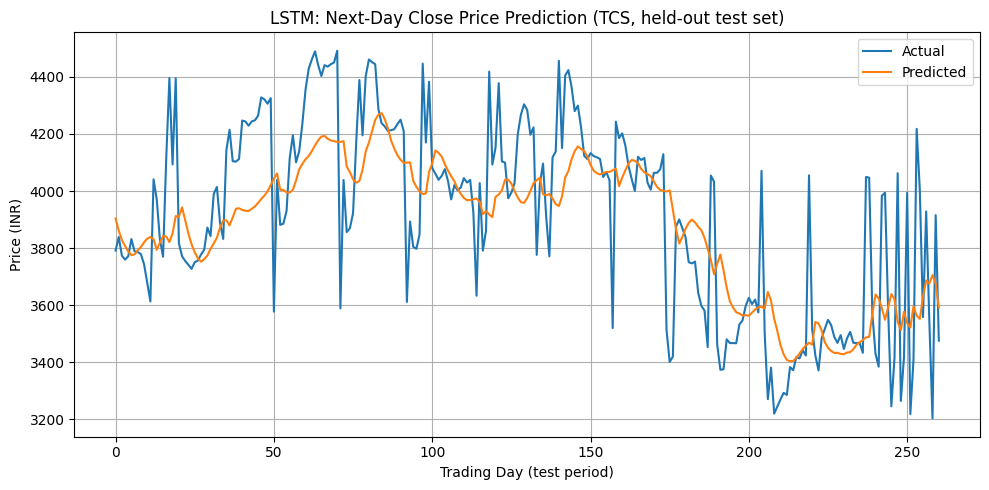

In [4]:
pred_scaled = model_lstm.predict(X_test, verbose=0)
pred = tscaler.inverse_transform(pred_scaled)
actual = tscaler.inverse_transform(y_test)

mse = mean_squared_error(actual, pred)
rmse = np.sqrt(mse)
print(f"LSTM Test MSE (rupees^2): {mse:,.2f}")
print(f"LSTM Test RMSE (rupees): {rmse:,.2f}   |   Average TCS close price: {tcs_feat['Close'].mean():,.2f}")
print(f"RMSE as % of average price: {100*rmse/tcs_feat['Close'].mean():.2f}%")

plt.figure(figsize=(10, 5))
plt.plot(actual, label="Actual")
plt.plot(pred, label="Predicted")
plt.title("LSTM: Next-Day Close Price Prediction (TCS, held-out test set)")
plt.xlabel("Trading Day (test period)")
plt.ylabel("Price (INR)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("lstm_prediction.png", dpi=100)
plt.show()

## 3. Reinforcement Learning — Q-Learning Trading Agent

**The idea, simply:** instead of predicting a price or a direction and then deciding what to do with that prediction, RL learns the **decision itself** — directly output "Buy / Hold / Sell" so as to maximize cumulative profit. It's a completely different paradigm from everything above:

- Linear/Logistic/KNN/CNN/LSTM = **supervised learning** — learn `f(inputs) → labelled target` (a price or a direction) from historical examples.
- RL = **learn by trial and error** — the agent takes actions in a simulated market, gets a reward (profit/loss), and updates its strategy (policy) to get more reward over time. There is no "correct label" at any point — only reward signal.

**Why this is the natural final step for this project:** predicting direction is not directly useful — a trader cares about *what to do*, not just *what will happen*. RL closes that gap by learning the policy end-to-end.

### How Q-learning specifically works
- **State**: a simplified snapshot of the market right now — here, whether the short-term trend (5-day SMA) is above the long-term trend (20-day SMA), whether RSI shows oversold/neutral/overbought, and whether the agent currently holds the stock or not.
- **Action**: Hold (0), Buy (1), or Sell (2).
- **Reward**: the % profit/loss realized when a position is closed (Sell).
- **Q-table**: a table of "how good is this action, in this state" — `Q[state][action]`. The agent updates it using the **Bellman equation**:

  `Q[s][a] ← Q[s][a] + α · ( reward + γ · max(Q[s_next]) − Q[s][a] )`

  where `α` (learning rate) controls how much each new experience updates the old estimate, and `γ` (discount factor) controls how much future reward matters vs immediate reward.
- **Epsilon-greedy exploration**: early in training the agent picks random actions often (to explore the space), and gradually shifts to picking the action with the highest known Q-value (to exploit what it has learned) — the classic **exploration vs exploitation** tradeoff central to all of RL.

In [5]:
def add_signals(df):
    df = df.copy()
    df["SMA_5"] = df["Close"].rolling(5).mean()
    df["SMA_20"] = df["Close"].rolling(20).mean()
    delta = df["Close"].diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = (-delta.clip(upper=0)).rolling(14).mean()
    rs = gain / loss.replace(0, np.nan)
    df["RSI"] = 100 - (100 / (1 + rs))
    df = df.dropna().reset_index(drop=True)
    df["trend"] = (df["SMA_5"] > df["SMA_20"]).astype(int)
    df["rsi_bucket"] = pd.cut(df["RSI"], bins=[-1, 30, 70, 101], labels=[0, 1, 2]).astype(int)
    return df

rl_df = add_signals(tcs)
prices = rl_df["Close"].values
trend = rl_df["trend"].values
rsi_bucket = rl_df["rsi_bucket"].values

n = len(rl_df)
split_rl = int(0.8 * n)

N_STATES = 2 * 3 * 2   # trend(2) x rsi_bucket(3) x position(2)
N_ACTIONS = 3          # 0=hold, 1=buy, 2=sell

def state_idx(t, position):
    return (trend[t] * 3 + rsi_bucket[t]) * 2 + position

def run_episode(start, end, Q, train=True, epsilon=0.0, alpha=0.1, gamma=0.95, track=False):
    position, entry_price, cash = 0, 0, 100000.0
    history = [cash]
    for t in range(start, end - 1):
        s = state_idx(t, position)
        if train and np.random.rand() < epsilon:
            a = random.randrange(N_ACTIONS)
        else:
            a = int(np.argmax(Q[s]))

        reward = 0.0
        if a == 1 and position == 0:
            position, entry_price = 1, prices[t]
        elif a == 2 and position == 1:
            reward = (prices[t] - entry_price) / entry_price
            cash *= (1 + reward)
            position = 0

        s_next = state_idx(t + 1, position)
        if train:
            Q[s][a] += alpha * (reward + gamma * np.max(Q[s_next]) - Q[s][a])

        if track:
            mark_to_market = cash * (1 + (prices[t] - entry_price) / entry_price) if position == 1 else cash
            history.append(mark_to_market)

    if position == 1:
        reward = (prices[end - 1] - entry_price) / entry_price
        cash *= (1 + reward)
        position = 0
    if track:
        history.append(cash)
    return cash, history

Q = np.zeros((N_STATES, N_ACTIONS))
EPISODES = 300
epsilon, epsilon_min, epsilon_decay = 1.0, 0.05, 0.995

for ep in range(EPISODES):
    run_episode(0, split_rl, Q, train=True, epsilon=epsilon)
    if epsilon > epsilon_min:
        epsilon *= epsilon_decay
    if (ep + 1) % 50 == 0:
        print(f"Episode {ep+1}/{EPISODES}  epsilon={epsilon:.3f}")

print("\nTraining complete.")

Episode 50/300  epsilon=0.778


Episode 100/300  epsilon=0.606


Episode 150/300  epsilon=0.471


Episode 200/300  epsilon=0.367


Episode 250/300  epsilon=0.286


Episode 300/300  epsilon=0.222

Training complete.


=== Q-LEARNING TRADING AGENT RESULTS (TCS) ===
Train period final portfolio: Rs.9,432,664.51  -> return 9332.66%
Test period (out-of-sample) final portfolio: Rs.143,545.93  -> return 43.55%
Buy & Hold benchmark (same test period): -8.62%


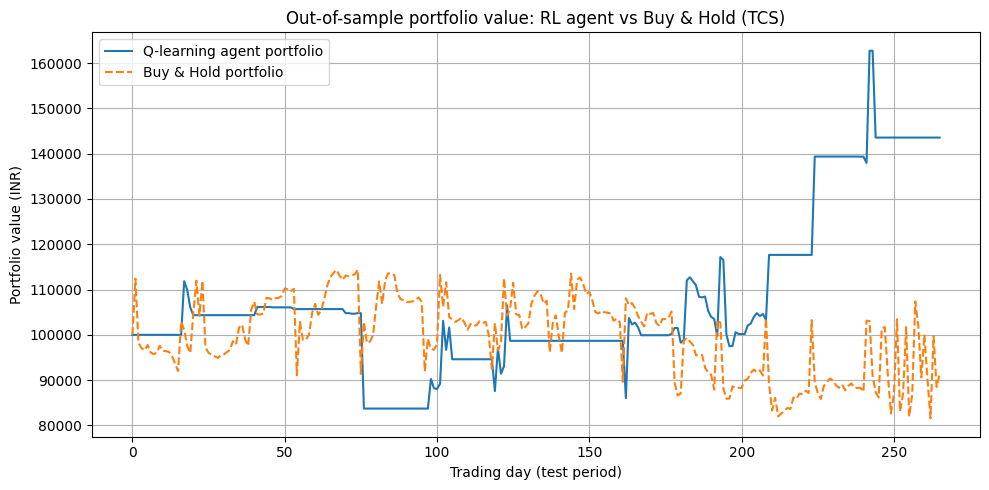

In [6]:
# Greedy evaluation (epsilon = 0, no exploration) on train and held-out test periods
train_final, train_hist = run_episode(0, split_rl, Q, train=False, epsilon=0.0, track=True)
test_final, test_hist = run_episode(split_rl, n, Q, train=False, epsilon=0.0, track=True)

initial = 100000.0
train_return = (train_final - initial) / initial * 100
test_return = (test_final - initial) / initial * 100
buy_hold_test = (prices[n - 1] - prices[split_rl]) / prices[split_rl] * 100

print("=== Q-LEARNING TRADING AGENT RESULTS (TCS) ===")
print(f"Train period final portfolio: Rs.{train_final:,.2f}  -> return {train_return:.2f}%")
print(f"Test period (out-of-sample) final portfolio: Rs.{test_final:,.2f}  -> return {test_return:.2f}%")
print(f"Buy & Hold benchmark (same test period): {buy_hold_test:.2f}%")

plt.figure(figsize=(10, 5))
bh_curve = initial * (prices[split_rl:n] / prices[split_rl])
plt.plot(test_hist[:len(bh_curve)], label="Q-learning agent portfolio")
plt.plot(bh_curve, label="Buy & Hold portfolio", linestyle="--")
plt.title("Out-of-sample portfolio value: RL agent vs Buy & Hold (TCS)")
plt.xlabel("Trading day (test period)")
plt.ylabel("Portfolio value (INR)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("rl_vs_buyhold.png", dpi=100)
plt.show()

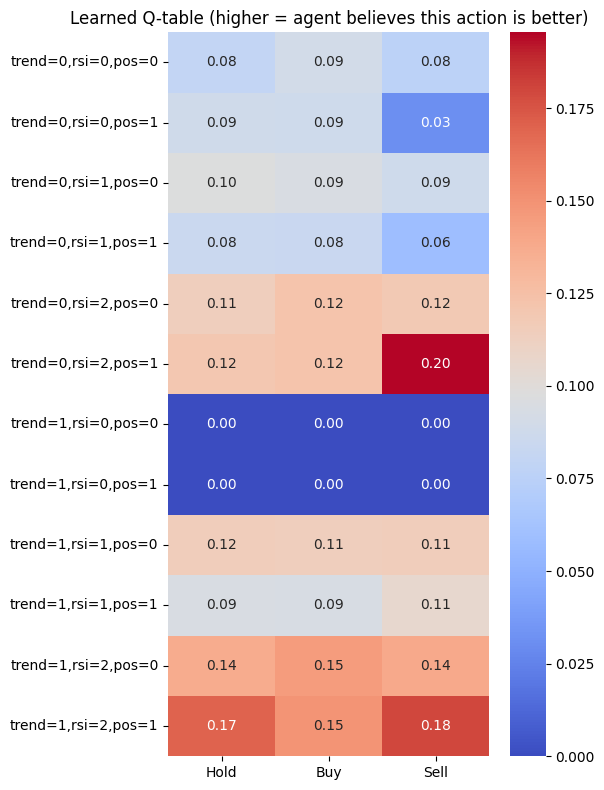

In [7]:
import seaborn as sns

state_labels = []
for tr in [0,1]:
    for rb in [0,1,2]:
        for pos in [0,1]:
            state_labels.append(f"trend={tr},rsi={rb},pos={pos}")

plt.figure(figsize=(6, 8))
sns.heatmap(Q, annot=True, fmt=".2f", cmap="coolwarm",
            xticklabels=["Hold","Buy","Sell"], yticklabels=state_labels)
plt.title("Learned Q-table (higher = agent believes this action is better)")
plt.tight_layout()
plt.savefig("q_table_heatmap.png", dpi=100)
plt.show()

## 4. Summary of this notebook's results

| Model | Task | Metric | Result |
|---|---|---|---|
| LSTM | Next-day price (TCS) | RMSE | See output above (also printed as % of average price) |
| Q-learning RL agent | Buy/Hold/Sell policy (TCS, out-of-sample) | Portfolio return | See output above, compared against Buy & Hold |

**Talking points for interviews:**
- LSTM vs CNN: both are sequence models; LSTM explicitly models order via gated memory, CNN via local sliding filters — similar performance ballpark on this data, but conceptually different tools worth contrasting if asked.
- RL is fundamentally different from everything before it: it's not predicting a number, it's learning a *policy* through trial-and-error and reward, using the Bellman equation to propagate long-term value estimates back through Q-values.
- The state space here is intentionally small and interpretable (trend × RSI bucket × position) — a natural next step (mentioned, not required to have run) is a **Deep Q-Network (DQN)**, replacing the table with a neural network so the agent can use richer, continuous state (raw OHLCV windows) instead of hand-crafted discrete buckets.
- Always report **both** the RL agent's return **and** a Buy & Hold benchmark on the same period — a positive return alone means nothing if the market itself went up that much anyway.